# LSTM Drifter Trajectory Prediction Results

Loads the artifacts produced by `run_lstm.py` (three LSTM variants × three seeds)
and `ablation.py` (17-run ablation around the default config), and shows the
trajectory plots, error CDF, combined comparison, training curves, and ablation
results on the same test set used by the baseline notebook.

In [ ]:
%matplotlib inline
import sys, csv, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

REPO = Path.cwd() if (Path.cwd() / "baselines").exists() else Path.cwd().parent
sys.path.insert(0, str(REPO / "lstm"))
import lstm as L

base = np.load(REPO / "baselines" / "baseline_predictions.npz", allow_pickle=True)
mine = np.load(REPO / "lstm" / "lstm_predictions.npz", allow_pickle=True)

y_test  = base["y_test"]
cur_lat = base["cur_lat_test"]
cur_lon = base["cur_lon_test"]
sample_idx = base["viz_sample_idx"]
row_labels = [str(x) for x in base["viz_row_labels"]]

data = L.load_data()
X_test_u = data["X_test_u"]
fi = data["fi"]
del data

# extend the baseline notebook scheme with LSTM colors
PALETTE = {
    "Persistence":                "#e74c3c",
    "Advection":                  "#e67e22",
    "Ridge":                      "#3498db",
    "Random Forest":              "#2ecc71",
    "PC-RF":                      "#9b59b6",
    "LSTM (vanilla)":             "#1abc9c",
    "LSTM (phys-residual)":       "#f1c40f",
    "LSTM (phys-residual+loss)":  "#c0392b",
}

MODELS = {
    "LSTM (vanilla)":            (mine["y_lstm_vanilla"],   mine["geo_lstm_vanilla"]),
    "LSTM (phys-residual)":      (mine["y_lstm_resid"],     mine["geo_lstm_resid"]),
    "LSTM (phys-residual+loss)": (mine["y_lstm_residloss"], mine["geo_lstm_residloss"]),
    "PC-RF":                     (base["y_pc_rf"],          base["geo_pc_rf"]),
    "Advection":                 (base["y_adv"],            base["geo_adv"]),
}
for name, (_, g) in MODELS.items():
    print(f"{name:28s}  mean_geo = {g.mean():.3f} km")


LSTM (vanilla)                mean_geo = 5.942 km
LSTM (phys-residual)          mean_geo = 5.882 km
LSTM (phys-residual+loss)     mean_geo = 5.884 km
PC-RF                         mean_geo = 6.859 km
Advection                     mean_geo = 8.721 km


## 1. Trajectory predictions on 12 fixed test samples

Same 12 indices the baseline notebook uses, grouped into low / medium / high RF
error tiers. Each panel shows the 8-step (48h) history, the true +24h position,
and the three LSTM predictions.

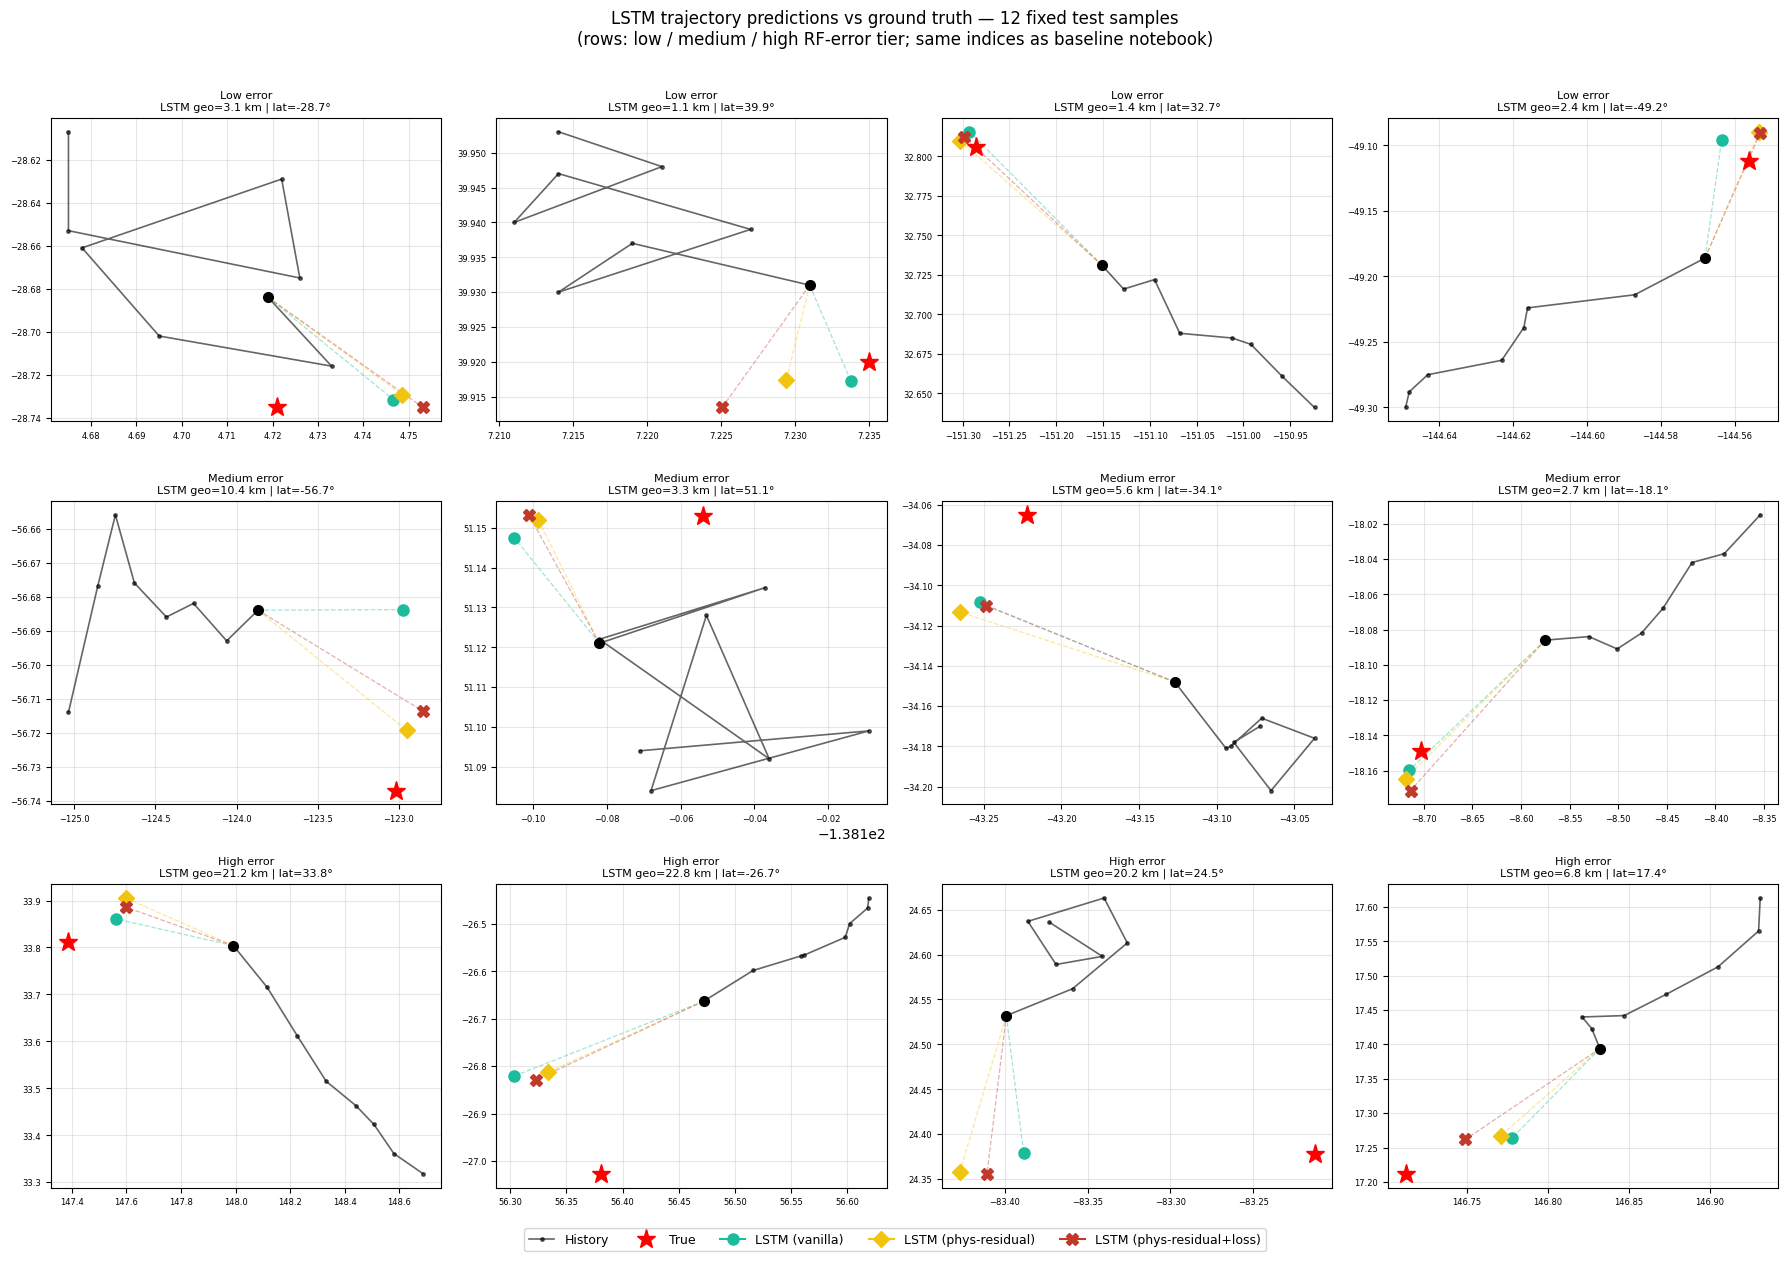

In [2]:
lstm_preds = [
    ("LSTM (vanilla)",            mine["y_lstm_vanilla"],   "o"),
    ("LSTM (phys-residual)",      mine["y_lstm_resid"],     "D"),
    ("LSTM (phys-residual+loss)", mine["y_lstm_residloss"], "X"),
]
best_geo = mine["geo_lstm_residloss"]

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
for plot_i, (si, row_lbl) in enumerate(zip(sample_idx, row_labels)):
    ax = axes[plot_i // 4][plot_i % 4]
    si = int(si)

    hlat = X_test_u[si, :, fi["latitude"]]
    hlon = X_test_u[si, :, fi["longitude"]]
    ax.plot(hlon, hlat, "k.-", lw=1.2, ms=5, alpha=0.6, label="History")

    clat = hlat[-1]; clon = hlon[-1]
    ax.plot(clon, clat, "ko", ms=7, zorder=8)

    tlat = clat + y_test[si, 0]
    tlon = clon + y_test[si, 1]
    ax.plot(tlon, tlat, "r*", ms=14, zorder=10, label="True")

    for pname, y_pred, pmark in lstm_preds:
        col = PALETTE[pname]
        plat = clat + y_pred[si, 0]
        plon = clon + y_pred[si, 1]
        ax.plot(plon, plat, marker=pmark, color=col, ms=8, zorder=9, label=pname)
        ax.plot([clon, plon], [clat, plat], "--", color=col, alpha=0.4, lw=0.9)

    ax.set_title(f"{row_lbl}\nLSTM geo={best_geo[si]:.1f} km | lat={clat:.1f}°",
                 fontsize=8)
    ax.tick_params(labelsize=6)
    ax.grid(True, alpha=0.3)

handles, labels_leg = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=5,
           fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle(
    "LSTM trajectory predictions vs ground truth — 12 fixed test samples\n"
    "(rows: low / medium / high RF-error tier; same indices as baseline notebook)",
    fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("lstm_trajectory_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 2. Error CDF on the full test set

Cumulative distribution of per-sample geodesic error. The three LSTM curves are
plotted as solid lines, the two reference baselines (PC-RF and Advection) dashed.

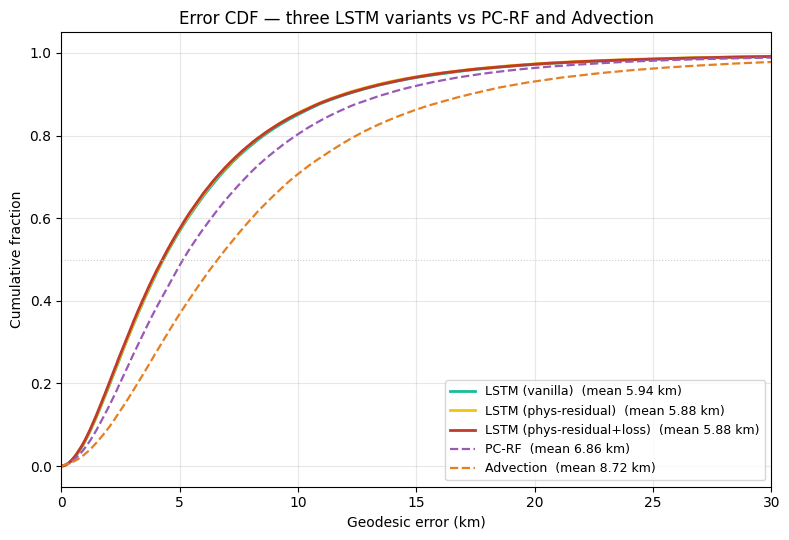

model                           <=5km   <=10km   <=20km
LSTM (vanilla)                  56.9%    85.1%    97.2%
LSTM (phys-residual)            57.2%    85.5%    97.4%
LSTM (phys-residual+loss)       57.4%    85.3%    97.3%
PC-RF                           48.6%    80.3%    96.4%
Advection                       36.9%    70.7%    93.1%


In [3]:
fig, ax = plt.subplots(figsize=(8, 5.5))
for name, (_, geo) in MODELS.items():
    g = np.sort(geo)
    yy = np.arange(1, len(g) + 1) / len(g)
    ls = "-" if "LSTM" in name else "--"
    lw = 2.0 if "LSTM" in name else 1.6
    ax.plot(g, yy, ls, color=PALETTE[name], lw=lw,
            label=f"{name}  (mean {geo.mean():.2f} km)")
ax.axhline(0.5, color="0.8", lw=0.8, ls=":")
ax.set_xlim(0, 30)
ax.set_xlabel("Geodesic error (km)")
ax.set_ylabel("Cumulative fraction")
ax.set_title("Error CDF — three LSTM variants vs PC-RF and Advection")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_error_cdf.png", dpi=150, bbox_inches="tight")
plt.show()

print(f'{"model":28s}  {"<=5km":>7s}  {"<=10km":>7s}  {"<=20km":>7s}')
for name, (_, g) in MODELS.items():
    print(f"{name:28s}  {(g<=5).mean():7.1%}  {(g<=10).mean():7.1%}  {(g<=20).mean():7.1%}")


## 3. Combined comparison: baselines + LSTM (multi-seed)

Pulls together the five baseline rows from `baseline_metrics.csv` and the three
LSTM rows (mean over seeds 7 / 42 / 123). The `Mean geo range (km)` column is
the max-minus-min across seeds and approximates a noise floor.

Model                      MAE lat (°)  MAE lon (°)  RMSE lat (°)  RMSE lon (°)  Mean geo (km)  Mean geo range (km)  Median geo (km)  P90 geo (km)
Persistence (Tier 1)       0.09797      0.16401      0.14693       0.79057       19.108                              14.208           39.715      
Advection (Tier 1)         0.05097      0.07267      0.08019       0.65753       8.721                               6.610            17.252      
Ridge (Tier 2)             0.04564      0.06506      0.07053       0.57196       7.801                               5.993            15.251      
Random Forest (Tier 2)     0.04281      0.06178      0.06550       0.70356       7.251                               5.488            14.425      
PC-RF (Tier 3)             0.04022      0.05906      0.06256       0.64392       6.859                               5.147            13.670      
LSTM (vanilla)             0.03470      0.05475      0.05500       0.71845       5.962          0.038                4

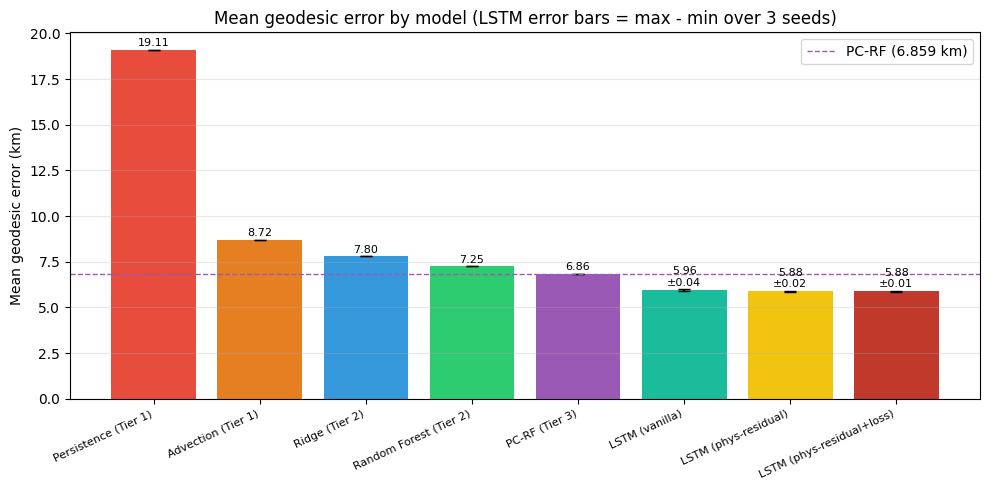

In [4]:
with open(REPO / "lstm" / "lstm_metrics.csv", encoding="utf-8") as f:
    rows = [r for r in csv.reader(f) if r]
header, body = rows[0], rows[1:]
w = [max(len(header[i]), *(len(r[i]) for r in body)) for i in range(len(header))]
print("  ".join(h.ljust(w[i]) for i, h in enumerate(header)))
for r in body:
    print("  ".join(c.ljust(w[i]) for i, c in enumerate(r)))

labels = [r[0] for r in body]
means  = [float(r[5]) for r in body]
ranges = [float(r[6]) if r[6] else 0.0 for r in body]
color_lookup = {
    "Persistence (Tier 1)":       PALETTE["Persistence"],
    "Advection (Tier 1)":         PALETTE["Advection"],
    "Ridge (Tier 2)":             PALETTE["Ridge"],
    "Random Forest (Tier 2)":     PALETTE["Random Forest"],
    "PC-RF (Tier 3)":             PALETTE["PC-RF"],
    "LSTM (vanilla)":             PALETTE["LSTM (vanilla)"],
    "LSTM (phys-residual)":       PALETTE["LSTM (phys-residual)"],
    "LSTM (phys-residual+loss)":  PALETTE["LSTM (phys-residual+loss)"],
}
colors = [color_lookup.get(l, "0.6") for l in labels]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(range(len(labels)), means, yerr=ranges, capsize=4,
              color=colors, error_kw=dict(elinewidth=1.2, ecolor="black"))
ax.axhline(6.859, color=PALETTE["PC-RF"], ls="--", lw=1, label="PC-RF (6.859 km)")
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=25, ha="right", fontsize=8)
ax.set_ylabel("Mean geodesic error (km)")
ax.set_title("Mean geodesic error by model (LSTM error bars = max - min over 3 seeds)")
for b, v, rg in zip(bars, means, ranges):
    txt = f"{v:.2f}" if rg == 0 else f"{v:.2f}\n±{rg:.2f}"
    ax.text(b.get_x() + b.get_width()/2, v + rg + 0.2, txt, ha="center", fontsize=8)
ax.legend()
ax.grid(True, axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


## 4. Validation training curves

Per-epoch validation mean geodesic km for the three LSTM variants. Each colour
plots three runs (one per seed); the solid line is seed 42 and the dashed lines
are seeds 7 and 123. Vertical spread between same-colour seeds visualises the
noise floor; the gap between colours is the model effect.

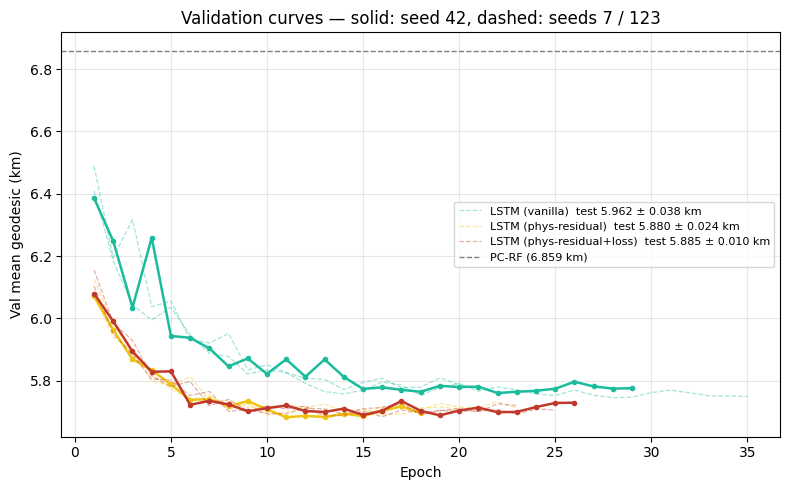

In [5]:
run = json.load(open(REPO / "lstm" / "lstm_run.json"))
cmap = {"LSTM (vanilla)":            PALETTE["LSTM (vanilla)"],
        "LSTM (phys-residual)":      PALETTE["LSTM (phys-residual)"],
        "LSTM (phys-residual+loss)": PALETTE["LSTM (phys-residual+loss)"]}

fig, ax = plt.subplots(figsize=(8, 5))
for key, rec in run["models"].items():
    col = cmap[rec["label"]]
    agg = rec["aggregated_test"]["mean_geo"]
    label = f"{rec['label']}  test {agg['mean']:.3f} ± {agg['range']:.3f} km"
    first = True
    for ps in rec["per_seed"]:
        ep = [h["epoch"] for h in ps["history"]]
        vg = [h["val_mean_geo"] for h in ps["history"]]
        solid = (ps["seed"] == 42)
        ax.plot(ep, vg, "-" if solid else "--", color=col,
                alpha=1.0 if solid else 0.4,
                lw=1.8 if solid else 0.9,
                marker="o" if solid else None, ms=3,
                label=label if first else None)
        first = False
ax.axhline(6.859, color="gray", ls="--", lw=1, label="PC-RF (6.859 km)")
ax.set_xlabel("Epoch")
ax.set_ylabel("Val mean geodesic (km)")
ax.set_title("Validation curves — solid: seed 42, dashed: seeds 7 / 123")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("lstm_val_curves.png", dpi=150, bbox_inches="tight")
plt.show()


## 5. Ablation study (17 runs)

Ablation around the spec default
(`h=128, l=2, dr=0.1, λ=1.0, seed=42, all 21 features, physics-residual+loss`):
capacity (3×3), dropout, λ_phys, feature subset (core-4 vs all-21), and seed
stability.

rank_by_val  tag               axis            hidden  layers  dropout  lambda_phys  features  seed  val_mean_geo  test_mean_geo  test_median  test_p90  epochs  wall_s
1            A_cap_h256_l3     capacity        256     3       0.1      1.0          all21     42    5.6204        5.8043         4.2232       11.8387   24      243.0 
2            A_cap_h128_l2     capacity        128     2       0.1      1.0          all21     42    5.6340        5.8328         4.2404       11.8887   25      365.8 
3            A_cap_h256_l2     capacity        256     2       0.1      1.0          all21     42    5.6342        5.8184         4.2291       11.8260   18      80.9  
4            C_lambda_lam0.1   lambda_phys     128     2       0.1      0.1          all21     42    5.6409        5.8317         4.2405       11.8710   25      130.0 
5            B_dropout_dr0.2   dropout         128     2       0.2      1.0          all21     42    5.6438        5.8288         4.2498       11.8354   25     

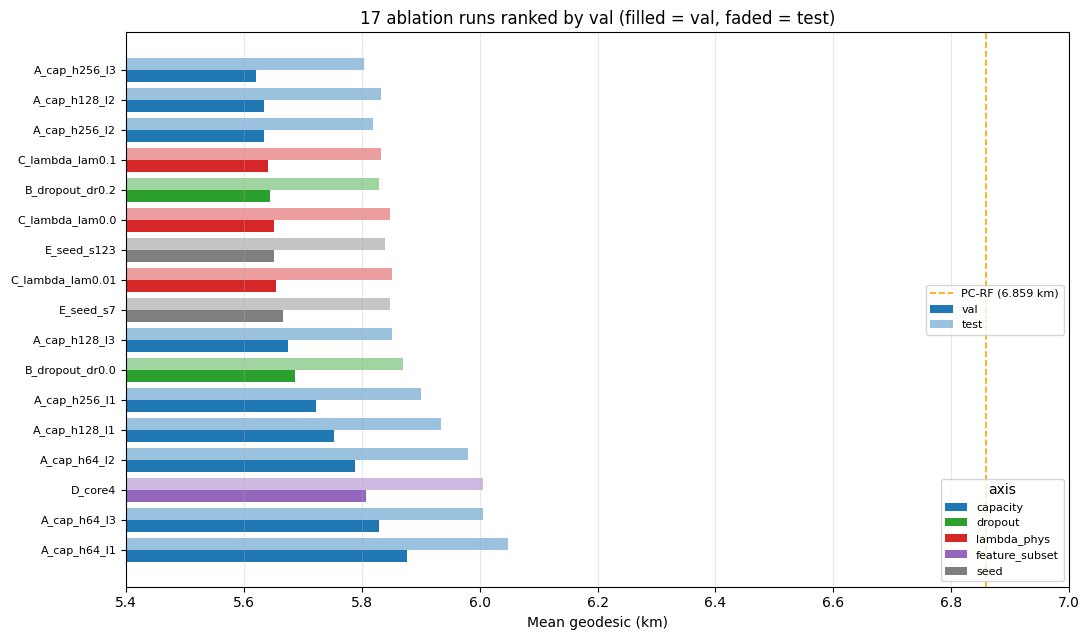

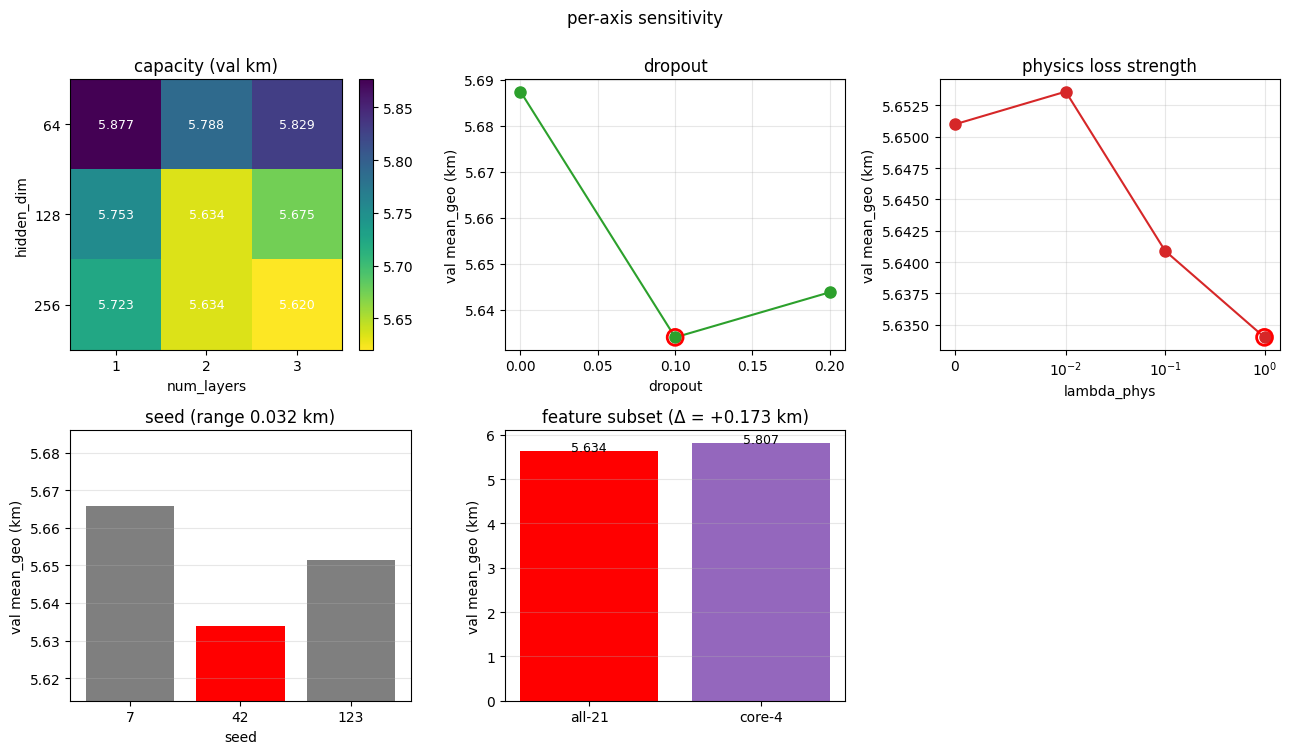

In [6]:
with open(REPO / "lstm" / "ablation_summary.csv", encoding="utf-8") as f:
    sw_rows = [r for r in csv.reader(f) if r]
sw_header, sw_body = sw_rows[0], sw_rows[1:]
w = [max(len(sw_header[i]), *(len(r[i]) for r in sw_body)) for i in range(len(sw_header))]
print("  ".join(h.ljust(w[i]) for i, h in enumerate(sw_header)))
for r in sw_body:
    print("  ".join(c.ljust(w[i]) for i, c in enumerate(r)))

tags = [r[1] for r in sw_body]
axes_ = [r[2] for r in sw_body]
val_geo = np.array([float(r[9]) for r in sw_body])
test_geo = np.array([float(r[10]) for r in sw_body])
axis_color = {"capacity": "tab:blue", "dropout": "tab:green", "lambda_phys": "tab:red",
              "feature_subset": "tab:purple", "seed": "tab:gray"}
bar_colors = [axis_color[a] for a in axes_]
ref_val = next(float(r[9]) for r in sw_body if r[1] == "A_cap_h128_l2")

from matplotlib.patches import Patch
fig, ax = plt.subplots(figsize=(11, 6.5))
yy = np.arange(len(tags))[::-1]
ax.barh(yy - 0.2, val_geo,  height=0.4, color=bar_colors,             label="val")
ax.barh(yy + 0.2, test_geo, height=0.4, color=bar_colors, alpha=0.45, label="test")
ax.set_yticks(yy); ax.set_yticklabels(tags, fontsize=8)
ax.axvline(6.859, color="orange", ls="--", lw=1.2, label="PC-RF (6.859 km)")
ax.set_xlabel("Mean geodesic (km)")
ax.set_xlim(5.4, 7.0)
ax.set_title("17 ablation runs ranked by val (filled = val, faded = test)")
leg = ax.legend(handles=[Patch(facecolor=c, label=a) for a, c in axis_color.items()],
                loc="lower right", fontsize=8, title="axis")
ax.add_artist(leg)
ax.legend(loc="center right", fontsize=8)
ax.grid(True, alpha=0.3, axis="x")
plt.tight_layout()
plt.savefig("lstm_ablation_ranking.png", dpi=150, bbox_inches="tight")
plt.show()

fig, axs = plt.subplots(2, 3, figsize=(13, 7.5))

hidden_vals, layer_vals = [64, 128, 256], [1, 2, 3]
cap = np.full((3, 3), np.nan)
for r in sw_body:
    if r[2] == "capacity":
        cap[hidden_vals.index(int(r[3])), layer_vals.index(int(r[4]))] = float(r[9])
ax = axs[0, 0]
im = ax.imshow(cap, cmap="viridis_r", aspect="auto")
ax.set_xticks(range(3)); ax.set_xticklabels(layer_vals)
ax.set_yticks(range(3)); ax.set_yticklabels(hidden_vals)
ax.set_xlabel("num_layers"); ax.set_ylabel("hidden_dim")
ax.set_title("capacity (val km)")
for i in range(3):
    for j in range(3):
        ax.text(j, i, f"{cap[i,j]:.3f}", ha="center", va="center", color="white", fontsize=9)
plt.colorbar(im, ax=ax)

ax = axs[0, 1]
dr_data = {0.1: ref_val}
for r in sw_body:
    if r[2] == "dropout": dr_data[float(r[5])] = float(r[9])
xs = sorted(dr_data); ys = [dr_data[x] for x in xs]
ax.plot(xs, ys, "o-", color="tab:green", ms=8)
ax.scatter([0.1], [ref_val], s=130, facecolor="none", edgecolor="red", lw=2, zorder=5)
ax.set_xlabel("dropout"); ax.set_ylabel("val mean_geo (km)")
ax.set_title("dropout"); ax.grid(True, alpha=0.3)

ax = axs[0, 2]
lam_data = {1.0: ref_val}
for r in sw_body:
    if r[2] == "lambda_phys": lam_data[float(r[6])] = float(r[9])
xs = sorted(lam_data); ys = [lam_data[x] for x in xs]
ax.plot(xs, ys, "o-", color="tab:red", ms=8)
ax.scatter([1.0], [ref_val], s=130, facecolor="none", edgecolor="red", lw=2, zorder=5)
ax.set_xscale("symlog", linthresh=0.01)
ax.set_xlabel("lambda_phys"); ax.set_ylabel("val mean_geo (km)")
ax.set_title("physics loss strength"); ax.grid(True, alpha=0.3)

ax = axs[1, 0]
seed_data = {42: ref_val}
for r in sw_body:
    if r[2] == "seed": seed_data[int(r[8])] = float(r[9])
xs = sorted(seed_data); ys = [seed_data[x] for x in xs]
ax.bar(range(len(xs)), ys, color=["red" if s == 42 else "tab:gray" for s in xs])
ax.set_xticks(range(len(xs))); ax.set_xticklabels(xs)
ax.set_ylim(min(ys) - 0.02, max(ys) + 0.02)
ax.set_xlabel("seed"); ax.set_ylabel("val mean_geo (km)")
ax.set_title(f"seed (range {max(ys)-min(ys):.3f} km)")
ax.grid(True, alpha=0.3, axis="y")

ax = axs[1, 1]
core4 = next(float(r[9]) for r in sw_body if r[1] == "D_core4")
ax.bar(["all-21", "core-4"], [ref_val, core4], color=["red", "tab:purple"])
for i, v in enumerate([ref_val, core4]):
    ax.text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=9)
ax.set_ylabel("val mean_geo (km)")
ax.set_title(f"feature subset (Δ = {core4 - ref_val:+.3f} km)")
ax.grid(True, alpha=0.3, axis="y")

axs[1, 2].axis("off")
fig.suptitle("per-axis sensitivity", fontsize=12, y=1.0)
plt.tight_layout()
plt.savefig("lstm_ablation_sensitivity.png", dpi=150, bbox_inches="tight")
plt.show()
